### Gaussian (Normal) Distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

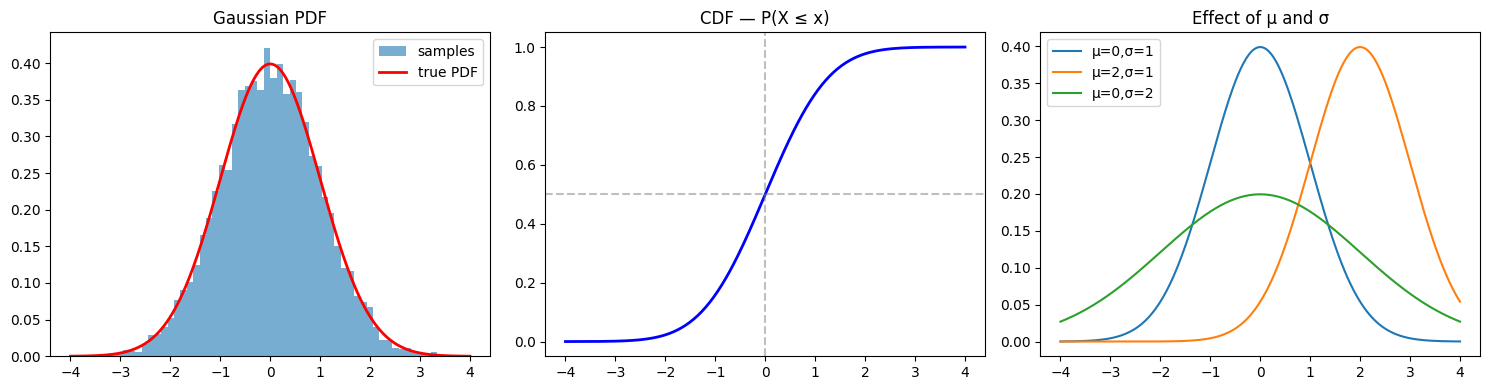

P(within 1σ): 0.6826894921370859
P(within 2σ): 0.9544997361036416
P(within 3σ): 0.9973002039367398


In [2]:
# Gaussian defined by two numbers: mean (μ) and std (σ)
mu    = 0       # center
sigma = 1       # spread

# sampling from it
samples = np.random.normal(mu, sigma, size=10000)

# the theoretical curve
x = np.linspace(-4, 4, 300)
pdf = stats.norm.pdf(x, mu, sigma)   # probability density function
cdf = stats.norm.cdf(x, mu, sigma)   # cumulative distribution function

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# plot 1: histogram of samples vs theoretical PDF
axes[0].hist(samples, bins=60, density=True, alpha=0.6, label='samples')
axes[0].plot(x, pdf, 'r-', linewidth=2, label='true PDF')
axes[0].set_title('Gaussian PDF')
axes[0].legend()

# plot 2: CDF
axes[1].plot(x, cdf, 'b-', linewidth=2)
axes[1].set_title('CDF — P(X ≤ x)')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)

# plot 3: different means and stds
for mu_, sigma_, label in [(0,1,'μ=0,σ=1'), (2,1,'μ=2,σ=1'), (0,2,'μ=0,σ=2')]:
    axes[2].plot(x, stats.norm.pdf(x, mu_, sigma_), label=label)
axes[2].set_title('Effect of μ and σ')
axes[2].legend()

plt.tight_layout()
plt.show()

# the 68-95-99.7 rule
print("P(within 1σ):", stats.norm.cdf(1) - stats.norm.cdf(-1))
print("P(within 2σ):", stats.norm.cdf(2) - stats.norm.cdf(-2))
print("P(within 3σ):", stats.norm.cdf(3) - stats.norm.cdf(-3))

Gaussian distribution: defined by mean μ (center) and std σ (spread).
PDF: probability density at each point (not a probability itself).
CDF: probability of being ≤ x. Always goes from 0 to 1.

68-95-99.7 rule:
~68% of data falls within 1σ of the mean
~95% within 2σ
~99.7% within 3σ

Used in ML:
- Linear regression assumes residuals are Gaussian
- Features are often standardized to N(0,1) before training
- Gaussian noise is added during data augmentation

### Bernoulli and Binomial

Expected heads: 0.7, Got: 0.702


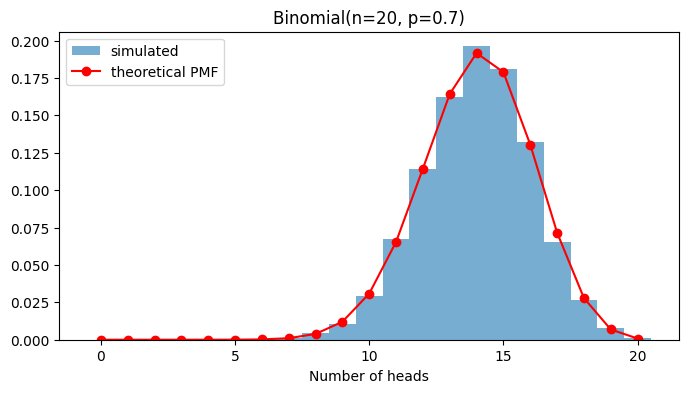

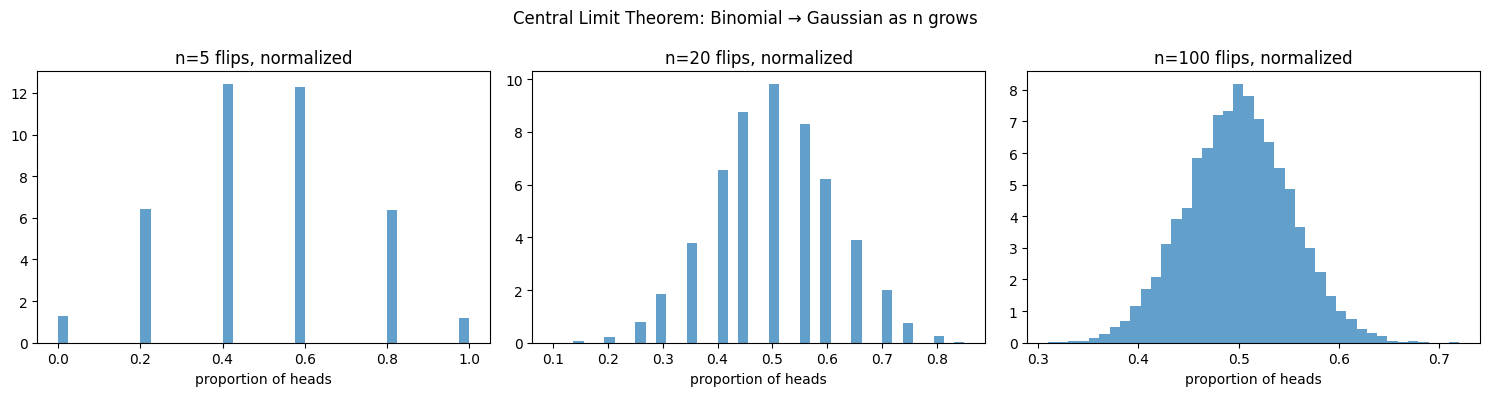

In [4]:
# Bernoulli: single coin flip with probability p of heads
p = 0.7
flips = np.random.binomial(n=1, p=p, size=10000)
print(f"Expected heads: {p}, Got: {flips.mean():.3f}")

# Binomial: count of heads in n flips
n_flips = 20
counts = np.random.binomial(n=n_flips, p=p, size=10000)

x_vals = np.arange(0, n_flips+1)
theoretical = stats.binom.pmf(x_vals, n=n_flips, p=p)

plt.figure(figsize=(8, 4))
plt.hist(counts, bins=np.arange(0, 22)-0.5, 
         density=True, alpha=0.6, label='simulated')
plt.plot(x_vals, theoretical, 'ro-', label='theoretical PMF')
plt.title(f'Binomial(n={n_flips}, p={p})')
plt.xlabel('Number of heads')
plt.legend()
plt.show()

# CLT: as n gets large, Binomial → Gaussian
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, [5, 20, 100]):
    samples = np.random.binomial(n=n, p=0.5, size=10000) / n
    ax.hist(samples, bins=40, density=True, alpha=0.7)
    ax.set_title(f'n={n} flips, normalized')
    ax.set_xlabel('proportion of heads')

plt.suptitle('Central Limit Theorem: Binomial → Gaussian as n grows')
plt.tight_layout()
plt.show()

Bernoulli: one binary event. Output is 0 or 1. Controlled by p.
Binomial: count of successes in n Bernoulli trials.

Central Limit Theorem (CLT): 
Average of many independent random variables → Gaussian,
regardless of the original distribution.
This is why Gaussian appears everywhere in statistics.

Used in ML:
- Logistic regression output is a Bernoulli probability
- Binary cross-entropy loss is derived from Bernoulli likelihood
- CLT justifies many statistical tests used in model evaluation

### Bayes Theorem

P(disease | positive test) = 0.161
Most people guess ~95%. Actual answer: 16.1%
This is the base rate fallacy.


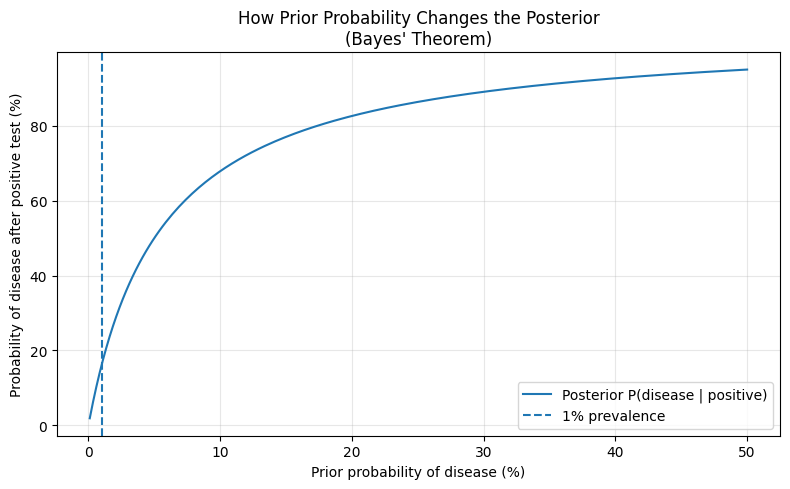

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Medical test example — the one that breaks everyone's intuition

# Disease affects 1% of population
# Test has 95% true positive rate
# Test has 5% false positive rate

p_disease = 0.01          # Prior: P(disease)
p_pos_given_dis = 0.95    # Likelihood: P(positive | disease)
p_pos_given_no = 0.05     # P(positive | no disease)

# P(positive) — total probability of testing positive
p_positive = (
    p_pos_given_dis * p_disease
    + p_pos_given_no * (1 - p_disease)
)

# Bayes' theorem:
# P(disease | positive) =
# P(positive | disease) * P(disease) / P(positive)

p_disease_given_pos = (
    p_pos_given_dis * p_disease
) / p_positive

print(f"P(disease | positive test) = {p_disease_given_pos:.3f}")
print(
    f"Most people guess ~95%. "
    f"Actual answer: {p_disease_given_pos * 100:.1f}%"
)
print("This is the base rate fallacy.")

# Show how prior probability changes the posterior
priors = np.linspace(0.001, 0.5, 200)

posteriors = []

for prior in priors:
    p_pos = (
        p_pos_given_dis * prior
        + p_pos_given_no * (1 - prior)
    )

    posterior = (p_pos_given_dis * prior) / p_pos
    posteriors.append(posterior)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    priors * 100,
    np.array(posteriors) * 100,
    label="Posterior P(disease | positive)"
)

plt.xlabel("Prior probability of disease (%)")
plt.ylabel("Probability of disease after positive test (%)")
plt.title("How Prior Probability Changes the Posterior\n(Bayes' Theorem)")

plt.axvline(
    1,
    linestyle="--",
    label="1% prevalence"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Bayes theorem: P(A|B) = P(B|A) * P(A) / P(B)
In ML language: posterior = likelihood * prior / evidence

Prior: your belief before seeing data
Likelihood: how probable is the data given your belief
Posterior: updated belief after seeing data

Training a model IS Bayesian updating:
- Prior = initial random weights
- Data = evidence
- Posterior = trained weights

The base rate fallacy: even a 95% accurate test gives only ~16%
probability of disease when prevalence is 1%. 
Always account for the prior.